# Error-Mitigation Shoot-out: TFIM Expectation Values on IBM Hardware

## What this notebook does

This is a **head-to-head benchmark of quantum error-mitigation stacks** run on a
real IBM superconducting QPU. The same physics problem is handed to several
different "estimators", each one a different strategy for turning a noisy device
into a trustworthy expectation value, and every one is scored against an **exact
classical reference**.

The question is simple to state and surprisingly hard to measure:

> Given the *same* circuit, the *same* observables, and the *same* backend, which
> provider returns the most accurate expectation values, how does that accuracy
> hold up as the system gets bigger, and what does each one cost in QPU time?

Every vendor advertises "better expectation values." This notebook turns that
claim into numbers.

## The contenders (the stacks being compared)

Each provider receives the identical TFIM circuit and the identical observables.
What differs is the mitigation machinery wrapped around the raw hardware:

| Provider | Stack | What it is doing |
| --- | --- | --- |
| **IBM raw** | `resilience_level = 0`, no twirling | Bare hardware — the control / lower bound. |
| **IBM TREX + twirling** | `resilience_level = 1` + measurement mitigation + gate/measure twirling | IBM's recommended lightweight mitigation for local observables. |
| **IBM ZNE** *(optional)* | `resilience_level = 2`, zero-noise extrapolation | More aggressive and far more expensive — off by default. |
| **Q-CTRL** | Performance Management estimator | Q-CTRL's automated suppression + mitigation pipeline. |
| **QESEM** | Qedma QESEM | Noise-learning error mitigation targeting a precision budget. |

IBM Runtime is fed the **ISA-transpiled** circuit with layout-applied observables
(as it requires); Q-CTRL and QESEM are fed the **abstract** circuit and do their
own transpilation/mapping — so each provider is used the way it is meant to be.

## How we get "ground truth"

The benchmark only works because the true answer is classically computable. The
circuit is deliberately **classically tractable** fixed-depth, local,
one-dimensional and we evaluate the exact expectation values with a
**matrix-product-state (MPS)** simulator. Because the state stays low-entanglement
at this depth, the MPS values are effectively exact and serve as the reference
every hardware result is graded against.

## What we measure

For every provider, every system size `n`, and every observable we record:

- **`absolute_error`** `|hardware value − ideal MPS value|`. The headline
  accuracy metric.
- **`std`** the provider's own reported uncertainty on the estimate.
- **`qpu_seconds`** best-effort QPU usage time, i.e. the *cost* of that accuracy.

The plots at the end place accuracy and cost side by side as a function of system
size, so you can see not just *who is most accurate*, but *who is most accurate per
second of quantum time* and *whose accuracy survives as the circuit grows wider*.

## What this particular run does

- **Observables across the full chain.** The three TFIM order parameters (`MZ`,
  `MX`, `ZZ`) are averaged over **every qubit and every nearest-neighbor bond**,
  not a sparse 8-site probe
  scaling test. Toggle with `evaluate_full_chain`.
- **Estimator primitive.** Providers return expectation values directly (rather
  than raw samples that we post-process), and no extra problem-reduction /
  pre-processing step is applied every provider sees the same untouched problem,
  which keeps the comparison clean. 

In [ ]:
# Import packages.

import numpy as np
import matplotlib.pyplot as plt
import json
import qiskit
from qiskit import qasm2
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.circuit.library import QFTGate
from qiskit import transpile, QuantumCircuit
from qiskit_ibm_catalog import QiskitFunctionsCatalog
import random
from qiskit import generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeTorino, FakeFez
from math import pi
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import UnitaryGate
from qiskit.quantum_info import SparsePauliOp
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from scipy.stats import unitary_group
import pandas as pd



In [2]:
import os
from dotenv import load_dotenv

load_dotenv()

IBM_QUANTUM_TOKEN = os.getenv("IBM_QUANTUM_TOKEN_EVIDA")
IBM_QUANTUM_INSTANCE = os.getenv("IBM_QUANTUM_INTANCE_CUA_EVIDA")

QiskitRuntimeService.save_account(
    token=IBM_QUANTUM_TOKEN,
    instance=IBM_QUANTUM_INSTANCE,
    overwrite=True,
)
service = QiskitRuntimeService()
backends = service.backends()
print(f"Account OK. {len(backends)} backend(s) available:")
for b in backends[:5]:
    print(f"  {b.name} ({b.num_qubits} qubits)")

Account OK. 6 backend(s) available:
  ibm_pittsburgh (156 qubits)
  ibm_boston (156 qubits)
  ibm_fez (156 qubits)
  ibm_miami (120 qubits)
  ibm_marrakesh (156 qubits)


In [3]:
catalog = QiskitFunctionsCatalog(channel="ibm_quantum_platform")

qesem_function = catalog.load("qedma/qesem")
perf_mgmt = catalog.load("q-ctrl/performance-management")

In [4]:
shot_count = 2**15
# hidden_string = "".join(random.choice("01") for _ in range(n))
backend =service.backend('ibm_pittsburgh')#FakeFez()  # AerSimulator()#
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)

# 1-D TFIM Benchmark: circuit, observables, and the full-chain change

## The circuit: fixed-depth 1-D transverse-field Ising model

The workload is a **fixed, non-variational** circuit modelled on the 1-D
transverse-field Ising model (TFIM). Starting from the uniform superposition
`|+...+>`, each layer applies:

1. **Even ZZ bonds** `RZZ(theta_zz)` on qubit pairs (0,1), (2,3), …
2. **Odd ZZ bonds** `RZZ(theta_zz)` on pairs (1,2), (3,4), …
3. **Transverse field** `RX(theta_x)` on every qubit.

This is a single, deterministic circuit per system size `n` — **no optimizer, no
parameter sweep, no variational loop**. That is exactly what a clean benchmark
needs: every provider sees the *same* reproducible circuit, and the only thing
that varies is the mitigation stack wrapped around the hardware. The model is also
**local** (nearest-neighbor only) and **shallow** (`tfim_layers = 2`), which is
what keeps it classically simulable and lets us compute a trustworthy reference.

We sweep `n` over `n_samples` (20 → 150 qubits) to watch how each provider's
accuracy and cost **scale with system size**.

## The observables ("operators") — now evaluated across the full chain

Every provider is scored on three bounded-weight observables, the natural local
order parameters of the TFIM:

| Label | Operator | Physical meaning |
| --- | --- | --- |
| `MZ` | average `<Z_i>` | longitudinal magnetisation density |
| `MX` | average `<X_i>` | transverse magnetisation density (the driven axis) |
| `ZZ` | average `<Z_i Z_{i+1}>` | nearest-neighbor bond / interaction-energy density |

**What changed in this version.** Previously these averages were taken over a
**sparse subset** of `num_probes = 8` sites/bonds spread along the chain — a cheap
"spot check" that held the term-count constant as `n` grew. This version evaluates
the operators **across the entire chain**:

```
MZ = (1/n)     * sum_{i=0}^{n-1}  <Z_i>
MX = (1/n)     * sum_{i=0}^{n-1}  <X_i>
ZZ = (1/(n-1)) * sum_{i=0}^{n-2}  <Z_i Z_{i+1}>
```

i.e. the true **intensive densities** over all `n` qubits and all `n-1` bonds.
Set `evaluate_full_chain = False` to fall back to the old sparse-probe behaviour.
The observable labels carry a `_full` / `_probe` suffix so every saved file and
plot makes the support mode explicit.

### Why full-chain is the right thing to measure

- **It tests the whole device, not 8 lucky qubits.** A sparse probe can sit
  entirely on the good part of a chip; a full-chain average exposes how a
  mitigation stack performs *everywhere*, which is what scaling claims rest on.
- **It is the physically meaningful quantity.** Global magnetisation and
  bond-energy *densities* are what you would actually report for a TFIM — not the
  value at a handful of sites.
- **It stays a fair, bounded measurement.** Each observable is normalised by its
  term count, so the magnitude stays `O(1)` and is comparable across all `n`.
  `MZ` and `ZZ` are *Z-type* (mutually qubit-wise commuting) and `MX` is *X-type*,
  so the full-chain version still needs only **two measurement settings**. Going
  full-chain adds Pauli *terms*, not measurement *bases* — it does not blow up the
  shot budget.

> **Cost caveat.** More terms *do* increase the work for providers whose cost
> scales with observable complexity (notably QESEM, which targets a precision
> budget). Read the accuracy gains from full-chain coverage alongside the
> `qpu_seconds` plot at the end.

The exact, full-chain reference for these same operators is computed with MPS in
the next section.

In [24]:
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.options import EstimatorOptions

os.makedirs("results/tfim_probe", exist_ok=True)

n_samples = [75]

tfim_layers = 8
theta_zz = 0.35
theta_x = 0.45
num_probes = 8

# ------------------------------------------------------------------
# Observable support: full chain vs. sparse probe subset.
#
#   evaluate_full_chain = True  (this run)
#       Each observable is averaged over the ENTIRE chain:
#           MZ = (1/n)     * sum_{i=0}^{n-1} <Z_i>
#           MX = (1/n)     * sum_{i=0}^{n-1} <X_i>
#           ZZ = (1/(n-1)) * sum_{i=0}^{n-2} <Z_i Z_{i+1}>
#       i.e. the intensive (per-site / per-bond) magnetisation and
#       bond-energy densities of the whole register.
#
#   evaluate_full_chain = False
#       Old behaviour: average over `num_probes` sites/edges spread
#       evenly across the chain (cheaper, but only samples a sparse
#       slice of the device).
# ------------------------------------------------------------------
evaluate_full_chain = True

qesem_precision = 0.1
qesem_max_execution_time = 600

run_qesem = True
run_qctrl = True
run_ibm_raw = True
run_ibm_trex_twirling = True

# Keep False this is too expensive!!!
run_ibm_zne = False

In [25]:
# tfim_rows = [row for row in tfim_rows if row["n"] not in [130, 140,150]]

In [26]:
def create_fixed_tfim_circuit(n, layers=2, theta_zz=0.35, theta_x=0.45):
    """
    Fixed-depth 1D transverse-field Ising-style circuit.

    This is NOT variational:
    - no optimizer
    - no parameter sweep
    - one fixed circuit per n
    """

    qc = QuantumCircuit(n)

    # Start from |+...+>
    qc.h(range(n))

    for _ in range(layers):
        # Even ZZ bonds
        for i in range(0, n - 1, 2):
            qc.rzz(theta_zz, i, i + 1)

        # Odd ZZ bonds
        for i in range(1, n - 1, 2):
            qc.rzz(theta_zz, i, i + 1)

        # Transverse field rotations
        for i in range(n):
            qc.rx(theta_x, i)

    return qc

In [27]:
def choose_probe_sites(n, num_probes=8, full_chain=False):
    """
    Choose the qubits that enter the single-site observables.

    full_chain=True   -> every qubit 0..n-1 (the full-chain average / density).
    full_chain=False  -> `num_probes` qubits spread evenly across the chain,
                         which keeps the observable term-count fixed as n grows.
    """

    if full_chain:
        return list(range(n))

    num_probes = min(num_probes, n)
    sites = np.linspace(0, n - 1, num_probes, dtype=int)
    sites = sorted(set(int(i) for i in sites))

    return sites


def choose_probe_edges(n, num_probes=8, full_chain=False):
    """
    Choose the nearest-neighbor bonds that enter the two-site observable.

    full_chain=True   -> every bond (i, i+1) for i in 0..n-2 (all n-1 bonds).
    full_chain=False  -> `num_probes` bonds spread evenly across the chain.
    """

    if full_chain:
        return [(i, i + 1) for i in range(n - 1)]

    num_probes = min(num_probes, n - 1)
    edge_starts = np.linspace(0, n - 2, num_probes, dtype=int)
    edges = sorted(set((int(i), int(i) + 1) for i in edge_starts))

    return edges


def average_single_pauli_observable(n, sites, pauli):
    """
    Build:
        (1/K) sum_i P_i

    where P is X, Y, or Z.
    """

    if len(sites) == 0:
        raise ValueError("sites cannot be empty")

    terms = []
    coeff = 1.0 / len(sites)

    for i in sites:
        label = ["I"] * n
        label[i] = pauli
        terms.append(("".join(label), coeff))

    return SparsePauliOp.from_list(terms)


def average_two_pauli_observable(n, edges, pauli_pair="ZZ"):
    """
    Build:
        (1/K) sum_(i,j) P_i P_j
    """

    if len(edges) == 0:
        raise ValueError("edges cannot be empty")

    terms = []
    coeff = 1.0 / len(edges)

    for i, j in edges:
        label = ["I"] * n
        label[i] = pauli_pair[0]
        label[j] = pauli_pair[1]
        terms.append(("".join(label), coeff))

    return SparsePauliOp.from_list(terms)


def tfim_probe_observables(n, num_probes=8, full_chain=False):
    """
    Three bounded-weight observables used to score every provider:

        MZ = average <Z_i>         longitudinal magnetisation
        MX = average <X_i>         transverse magnetisation (the driven axis)
        ZZ = average <Z_i Z_{i+1}> nearest-neighbor bond / interaction energy

    With full_chain=True these are the *intensive full-chain densities*, each
    normalised by its number of terms so the magnitude stays O(1) and is
    directly comparable across all values of n:

        MZ = (1/n)     sum_i  <Z_i>
        MX = (1/n)     sum_i  <X_i>
        ZZ = (1/(n-1)) sum_i  <Z_i Z_{i+1}>

    All three are weight-<=2 Pauli sums. MZ and ZZ are Z-type (mutually
    qubit-wise commuting) and MX is X-type, so even the full-chain version
    needs only two measurement settings -- it adds Pauli *terms*, not
    measurement *bases*. That keeps the comparison fair (and the shot budget
    bounded) for the IBM Estimator, the Q-CTRL Estimator, and QESEM.

    Labels carry a `_full` / `_probe` suffix so every saved file, table, and
    plot makes the support mode explicit.
    """

    sites = choose_probe_sites(n, num_probes=num_probes, full_chain=full_chain)
    edges = choose_probe_edges(n, num_probes=num_probes, full_chain=full_chain)

    observables = [
        average_single_pauli_observable(n, sites, "Z"),
        average_single_pauli_observable(n, sites, "X"),
        average_two_pauli_observable(n, edges, "ZZ"),
    ]

    suffix = "full" if full_chain else "probe"

    labels = [
        f"MZ_{suffix}",
        f"MX_{suffix}",
        f"ZZ_{suffix}",
    ]

    metadata = {
        "full_chain": full_chain,
        "probe_sites": sites,
        "probe_edges": edges,
        "num_sites": len(sites),
        "num_edges": len(edges),
    }

    return observables, labels, metadata


## Ideal MPS reference

Before touching hardware we compute the **exact** expectation values with a
matrix-product-state simulator (`AerSimulator(method="matrix_product_state")`).
At this depth the TFIM state stays low-entanglement, so the MPS result is
effectively exact it is the ground truth that every provider's `absolute_error`
is measured against.

In [28]:
def ideal_expectations_mps(circuit, observables, observable_labels):
    """
    Compute ideal expectation values using Qiskit Aer MPS simulation.

    This is suitable for fixed-depth 1D TFIM circuits:
    - local interactions,
    - shallow depth,
    - bounded-weight observables,
    - n = 20, 40, 60, 80.

    Returns:
        ideal_evs: np.array
        ideal_metadata: dict
    """

    n = circuit.num_qubits
    sim_circuit = circuit.copy()

    for obs, label in zip(observables, observable_labels):
        sim_circuit.save_expectation_value(
            obs,
            qubits=list(range(n)),
            label=f"ideal_{label}",
        )

    simulator = AerSimulator(
        method="matrix_product_state",
        matrix_product_state_max_bond_dimension=None,
        matrix_product_state_truncation_threshold=1e-16,
        mps_log_data=True,
    )

    job = simulator.run(sim_circuit, shots=1)
    result = job.result()
    data = result.data(0)

    ideal_evs = np.array(
        [
            float(np.real(data[f"ideal_{label}"]))
            for label in observable_labels
        ],
        dtype=float,
    )

    try:
        ideal_metadata = result.results[0].metadata
    except Exception:
        ideal_metadata = {}

    return ideal_evs, ideal_metadata

## IBM Estimator options

These helpers build the IBM Runtime `EstimatorOptions` for each rung of the IBM
ladder: **raw** (`resilience_level = 0`, no mitigation, no twirling the control),
the recommended **TREX + twirling** mitigation (`resilience_level = 1`,
measurement mitigation plus gate & measurement twirling), and the optional,
expensive **ZNE** (`resilience_level = 2`). `safe_set_nested` sets each nested
option defensively, so a field renamed in a future Qiskit Runtime release only
warns instead of crashing the whole sweep.

In [29]:
def safe_set_nested(obj, dotted_path, value, required=False):
    """
    Safely set nested option fields such as:
        resilience.measure_mitigation
        twirling.enable_gates

    If the field is missing, print a warning instead of crashing.
    """

    parts = dotted_path.split(".")
    target = obj

    for part in parts[:-1]:
        if not hasattr(target, part):
            message = f"Option path missing: {dotted_path}"
            if required:
                raise AttributeError(message)
            print("Warning:", message)
            return False

        target = getattr(target, part)

    final_attr = parts[-1]

    if not hasattr(target, final_attr):
        message = f"Option field missing: {dotted_path}"
        if required:
            raise AttributeError(message)
        print("Warning:", message)
        return False

    setattr(target, final_attr, value)
    return True


def make_ibm_raw_options(shots):
    """
    IBM raw baseline:
    - resilience_level = 0
    - no explicit mitigation
    - no explicit twirling
    """

    options = EstimatorOptions()
    options.default_shots = shots
    options.resilience_level = 0

    safe_set_nested(options, "resilience.measure_mitigation", False)
    safe_set_nested(options, "resilience.zne_mitigation", False)
    safe_set_nested(options, "resilience.pec_mitigation", False)

    safe_set_nested(options, "twirling.enable_gates", False)
    safe_set_nested(options, "twirling.enable_measure", False)

    return options


def make_ibm_trex_twirling_options(shots):
    """
    Recommended IBM mitigation for this benchmark:
    - TREX / measurement mitigation
    - gate twirling
    - measurement twirling
    - no ZNE
    - no PEC

    This is much lighter than ZNE/PEC and makes sense for local observables.
    """

    options = EstimatorOptions()
    options.default_shots = shots
    options.resilience_level = 1

    safe_set_nested(options, "resilience.measure_mitigation", True)

    safe_set_nested(options, "resilience.zne_mitigation", False)
    safe_set_nested(options, "resilience.pec_mitigation", False)

    safe_set_nested(options, "twirling.enable_gates", True)
    safe_set_nested(options, "twirling.enable_measure", True)

    return options


def make_ibm_zne_options(shots):
    """
    Optional expensive IBM comparison:
    - measurement mitigation
    - ZNE
    - gate/measure twirling

    Keep run_ibm_zne = False unless you intentionally want the extra cost.
    """

    options = EstimatorOptions()
    options.default_shots = shots
    options.resilience_level = 2

    safe_set_nested(options, "resilience.measure_mitigation", True)
    safe_set_nested(options, "resilience.zne_mitigation", True)
    safe_set_nested(options, "resilience.pec_mitigation", False)

    safe_set_nested(options, "twirling.enable_gates", True)
    safe_set_nested(options, "twirling.enable_measure", True)

    return options

## Collect Data

Utility functions for the run loop: pulling a **job ID** and a best-effort
**QPU-seconds** figure out of whatever job object each provider returns (IBM
Runtime, Q-CTRL, QESEM, and serverless jobs all expose usage differently),
extracting expectation values and standard deviations from a `PubResult`, and
flattening everything into tidy per-observable rows and JSON for later
analysis.

In [30]:
def get_job_id(job):
    """
    Extract job ID from IBM Runtime or Qiskit Function / Serverless jobs.
    """

    for attr in ["job_id", "id"]:
        value = getattr(job, attr, None)

        if callable(value):
            try:
                return value()
            except TypeError:
                pass

        if value is not None and not callable(value):
            return str(value)

    for attr in ["_job_id", "_id"]:
        value = getattr(job, attr, None)

        if value is not None:
            return str(value)

    return None


def get_qpu_seconds(job):
    """
    Best-effort extraction of QPU usage time.

    Returns:
        qpu_seconds, qpu_time_source

    If unavailable, returns:
        np.nan, "unavailable"
    """

    # IBM Runtime RuntimeJobV2: usage_estimation
    try:
        usage = getattr(job, "usage_estimation", None)

        if callable(usage):
            usage = usage()

        if isinstance(usage, dict):
            if "quantum_seconds" in usage:
                return float(usage["quantum_seconds"]), "usage_estimation.quantum_seconds"
            if "seconds" in usage:
                return float(usage["seconds"]), "usage_estimation.seconds"

    except Exception:
        pass

    # IBM Runtime metrics
    try:
        metrics = job.metrics()

        if isinstance(metrics, dict):
            usage = metrics.get("usage", None)

            if isinstance(usage, dict):
                if "quantum_seconds" in usage:
                    return float(usage["quantum_seconds"]), "metrics.usage.quantum_seconds"
                if "seconds" in usage:
                    return float(usage["seconds"]), "metrics.usage.seconds"

            if "usage" in metrics and isinstance(metrics["usage"], (int, float)):
                return float(metrics["usage"]), "metrics.usage"

    except Exception:
        pass

    # Some clients expose usage()
    try:
        usage = job.usage()

        if isinstance(usage, dict):
            if "quantum_seconds" in usage:
                return float(usage["quantum_seconds"]), "usage.quantum_seconds"
            if "seconds" in usage:
                return float(usage["seconds"]), "usage.seconds"

    except Exception:
        pass

    # Serverless / Qiskit Functions may expose underlying runtime jobs.
    try:
        runtime_jobs = job.runtime_jobs()

        total_qpu_seconds = 0.0
        found_any = False

        for runtime_job in runtime_jobs:
            qpu_seconds, source = get_qpu_seconds(runtime_job)

            if not np.isnan(qpu_seconds):
                total_qpu_seconds += qpu_seconds
                found_any = True

        if found_any:
            return total_qpu_seconds, "sum(runtime_jobs.qpu_seconds)"

    except Exception:
        pass

    return np.nan, "unavailable"


def extract_evs_and_stds(pub_result):
    """
    Extract expectation values and standard deviations from a PubResult.
    """

    evs = np.asarray(pub_result.data.evs, dtype=float).ravel()

    if hasattr(pub_result.data, "stds"):
        stds = np.asarray(pub_result.data.stds, dtype=float).ravel()
    else:
        stds = np.full_like(evs, np.nan, dtype=float)

    return evs, stds


def build_tfim_result_rows(
    provider_name,
    job_id,
    qpu_seconds,
    qpu_time_source,
    n,
    observable_labels,
    evs,
    stds,
    ideal_evs,
):
    rows = []

    for k, label in enumerate(observable_labels):
        ev = float(evs[k])
        std = float(stds[k]) if not np.isnan(stds[k]) else np.nan
        ideal = float(ideal_evs[k])
        absolute_error = abs(ev - ideal)

        rows.append(
            {
                "provider": provider_name,
                "job_id": job_id,
                "qpu_seconds": qpu_seconds,
                "qpu_time_source": qpu_time_source,
                "n": n,
                "observable": label,
                "expectation_value": ev,
                "std": std,
                "ideal": ideal,
                "absolute_error": absolute_error,
            }
        )

    return rows


def to_jsonable(obj):
    """
    Convert numpy types to Python-native types for JSON.
    """

    if isinstance(obj, np.ndarray):
        return obj.tolist()

    if isinstance(obj, (np.integer,)):
        return int(obj)

    if isinstance(obj, (np.floating,)):
        return float(obj)

    if isinstance(obj, dict):
        return {k: to_jsonable(v) for k, v in obj.items()}

    if isinstance(obj, list):
        return [to_jsonable(v) for v in obj]

    if isinstance(obj, tuple):
        return [to_jsonable(v) for v in obj]

    return obj


def save_json(filepath, payload):
    with open(filepath, "w") as f:
        json.dump(to_jsonable(payload), f, indent=4)

## Run the code!

The main sweep. For every system size `n` we build the circuit and the full-chain
observables, compute the ideal MPS reference, then submit the **same** problem to
each enabled provider, score every result against the reference, and persist it.
IBM Runtime receives the **ISA-transpiled** circuit with layout-applied
observables (as it requires); Q-CTRL and QESEM receive the **abstract** circuit
and do their own mapping. Partial results are written after every `n`, so a
failure late in the sweep never discards the work already done.

In [31]:
# tfim_rows = []

for n in n_samples:
    support_label = "full-chain" if evaluate_full_chain else f"{num_probes}-probe"
    print("=" * 80)
    print(f"Running fixed-depth TFIM {support_label} benchmark with n={n}")
    print("=" * 80)

    circuit = create_fixed_tfim_circuit(
        n=n,
        layers=tfim_layers,
        theta_zz=theta_zz,
        theta_x=theta_x,
    )

    observables, observable_labels, probe_metadata = tfim_probe_observables(
        n=n,
        num_probes=num_probes,
        full_chain=evaluate_full_chain,
    )

    print(
        f"Observable support: {probe_metadata['num_sites']} sites, "
        f"{probe_metadata['num_edges']} bonds "
        f"(full_chain={probe_metadata['full_chain']})"
    )

    # ============================================================
    # Ideal MPS reference
    # ============================================================

    print("Computing ideal MPS reference...")

    ideal_evs, ideal_metadata = ideal_expectations_mps(
        circuit=circuit,
        observables=observables,
        observable_labels=observable_labels,
    )

    print("Ideal EVs:")
    for label, value in zip(observable_labels, ideal_evs):
        print(f"  {label}: {value:.8f}")

    # IBM Runtime requires ISA circuit and layout-applied observables.
    # Q-CTRL and QESEM should receive the abstract circuit.
    print("Transpiling circuit for IBM Runtime...")
    isa_circuit = pm.run(circuit)

    isa_observables = [
        obs.apply_layout(isa_circuit.layout)
        for obs in observables
    ]

    # ============================================================
    # 1. IBM RAW
    # ============================================================

    if run_ibm_raw:
        print("\nSubmitting IBM raw Estimator job...")

        ibm_raw_options = make_ibm_raw_options(shot_count)
        ibm_raw_estimator = Estimator(mode=backend, options=ibm_raw_options)

        ibm_raw_job = ibm_raw_estimator.run(
            [(isa_circuit, isa_observables)]
        )

        ibm_raw_job_id = get_job_id(ibm_raw_job)
        print("IBM raw job ID:", ibm_raw_job_id)

        ibm_raw_result = ibm_raw_job.result()
        ibm_raw_pub_result = ibm_raw_result[0]

        ibm_raw_evs, ibm_raw_stds = extract_evs_and_stds(ibm_raw_pub_result)

        ibm_raw_qpu_seconds, ibm_raw_qpu_source = get_qpu_seconds(ibm_raw_job)

        tfim_rows.extend(
            build_tfim_result_rows(
                provider_name="IBM raw",
                job_id=ibm_raw_job_id,
                qpu_seconds=ibm_raw_qpu_seconds,
                qpu_time_source=ibm_raw_qpu_source,
                n=n,
                observable_labels=observable_labels,
                evs=ibm_raw_evs,
                stds=ibm_raw_stds,
                ideal_evs=ideal_evs,
            )
        )

        ibm_raw_json = {
            "provider": "IBM raw",
            "job_id": ibm_raw_job_id,
            "qpu_seconds": ibm_raw_qpu_seconds,
            "qpu_time_source": ibm_raw_qpu_source,
            "n": n,
            "tfim_layers": tfim_layers,
            "theta_zz": theta_zz,
            "theta_x": theta_x,
            "num_probes": num_probes,
            "probe_metadata": probe_metadata,
            "observable_labels": observable_labels,
            "ideal_evs": ideal_evs,
            "ideal_metadata": ideal_metadata,
            "evs": ibm_raw_evs,
            "stds": ibm_raw_stds,
            "options_label": "resilience_0_no_twirling",
        }

        save_json(
            f"results/tfim_probe/IBM_RAW_TFIM_n{n}.json",
            ibm_raw_json,
        )

    # ============================================================
    # 2. IBM TREX + TWIRLING
    # ============================================================

    if run_ibm_trex_twirling:
        print("\nSubmitting IBM TREX + twirling Estimator job...")

        ibm_mit_options = make_ibm_trex_twirling_options(shot_count)
        ibm_mit_estimator = Estimator(mode=backend, options=ibm_mit_options)

        ibm_mit_job = ibm_mit_estimator.run(
            [(isa_circuit, isa_observables)]
        )

        ibm_mit_job_id = get_job_id(ibm_mit_job)
        print("IBM TREX + twirling job ID:", ibm_mit_job_id)

        ibm_mit_result = ibm_mit_job.result()
        ibm_mit_pub_result = ibm_mit_result[0]

        ibm_mit_evs, ibm_mit_stds = extract_evs_and_stds(ibm_mit_pub_result)

        ibm_mit_qpu_seconds, ibm_mit_qpu_source = get_qpu_seconds(ibm_mit_job)

        tfim_rows.extend(
            build_tfim_result_rows(
                provider_name="IBM TREX + twirling",
                job_id=ibm_mit_job_id,
                qpu_seconds=ibm_mit_qpu_seconds,
                qpu_time_source=ibm_mit_qpu_source,
                n=n,
                observable_labels=observable_labels,
                evs=ibm_mit_evs,
                stds=ibm_mit_stds,
                ideal_evs=ideal_evs,
            )
        )

        ibm_mit_json = {
            "provider": "IBM TREX + twirling",
            "job_id": ibm_mit_job_id,
            "qpu_seconds": ibm_mit_qpu_seconds,
            "qpu_time_source": ibm_mit_qpu_source,
            "n": n,
            "tfim_layers": tfim_layers,
            "theta_zz": theta_zz,
            "theta_x": theta_x,
            "num_probes": num_probes,
            "probe_metadata": probe_metadata,
            "observable_labels": observable_labels,
            "ideal_evs": ideal_evs,
            "ideal_metadata": ideal_metadata,
            "evs": ibm_mit_evs,
            "stds": ibm_mit_stds,
            "options_label": "trex_measure_mitigation_gate_and_measure_twirling",
        }

        save_json(
            f"results/tfim_probe/IBM_TREX_TWIRLING_TFIM_n{n}.json",
            ibm_mit_json,
        )

    # ============================================================
    # Optional IBM ZNE
    # ============================================================

    if run_ibm_zne:
        print("\nSubmitting IBM ZNE Estimator job...")

        ibm_zne_options = make_ibm_zne_options(shot_count)
        ibm_zne_estimator = Estimator(mode=backend, options=ibm_zne_options)

        ibm_zne_job = ibm_zne_estimator.run(
            [(isa_circuit, isa_observables)]
        )

        ibm_zne_job_id = get_job_id(ibm_zne_job)
        print("IBM ZNE job ID:", ibm_zne_job_id)

        ibm_zne_result = ibm_zne_job.result()
        ibm_zne_pub_result = ibm_zne_result[0]

        ibm_zne_evs, ibm_zne_stds = extract_evs_and_stds(ibm_zne_pub_result)

        ibm_zne_qpu_seconds, ibm_zne_qpu_source = get_qpu_seconds(ibm_zne_job)

        tfim_rows.extend(
            build_tfim_result_rows(
                provider_name="IBM ZNE",
                job_id=ibm_zne_job_id,
                qpu_seconds=ibm_zne_qpu_seconds,
                qpu_time_source=ibm_zne_qpu_source,
                n=n,
                observable_labels=observable_labels,
                evs=ibm_zne_evs,
                stds=ibm_zne_stds,
                ideal_evs=ideal_evs,
            )
        )

        ibm_zne_json = {
            "provider": "IBM ZNE",
            "job_id": ibm_zne_job_id,
            "qpu_seconds": ibm_zne_qpu_seconds,
            "qpu_time_source": ibm_zne_qpu_source,
            "n": n,
            "tfim_layers": tfim_layers,
            "theta_zz": theta_zz,
            "theta_x": theta_x,
            "num_probes": num_probes,
            "probe_metadata": probe_metadata,
            "observable_labels": observable_labels,
            "ideal_evs": ideal_evs,
            "ideal_metadata": ideal_metadata,
            "evs": ibm_zne_evs,
            "stds": ibm_zne_stds,
            "options_label": "zne_trex_twirling",
        }

        save_json(
            f"results/tfim_probe/IBM_ZNE_TFIM_n{n}.json",
            ibm_zne_json,
        )

    # ============================================================
    # 3. Q-CTRL ESTIMATOR
    # ============================================================

    if run_qctrl:
        print("\nSubmitting Q-CTRL Estimator job...")

        # Q-CTRL should receive abstract circuits, not ISA-transpiled circuits.
        qctrl_job = perf_mgmt.run(
            primitive="estimator",
            pubs=[(circuit, observables)],
            backend_name=backend.name,
            options={
                "default_shots": shot_count,
            },
        )

        qctrl_job_id = get_job_id(qctrl_job)
        print("Q-CTRL job ID:", qctrl_job_id)

        qctrl_result = qctrl_job.result()
        qctrl_pub_result = qctrl_result[0]

        qctrl_evs, qctrl_stds = extract_evs_and_stds(qctrl_pub_result)

        qctrl_qpu_seconds, qctrl_qpu_source = get_qpu_seconds(qctrl_job)

        tfim_rows.extend(
            build_tfim_result_rows(
                provider_name="Q-CTRL",
                job_id=qctrl_job_id,
                qpu_seconds=qctrl_qpu_seconds,
                qpu_time_source=qctrl_qpu_source,
                n=n,
                observable_labels=observable_labels,
                evs=qctrl_evs,
                stds=qctrl_stds,
                ideal_evs=ideal_evs,
            )
        )

        qctrl_json = {
            "provider": "Q-CTRL",
            "job_id": qctrl_job_id,
            "qpu_seconds": qctrl_qpu_seconds,
            "qpu_time_source": qctrl_qpu_source,
            "n": n,
            "tfim_layers": tfim_layers,
            "theta_zz": theta_zz,
            "theta_x": theta_x,
            "num_probes": num_probes,
            "probe_metadata": probe_metadata,
            "observable_labels": observable_labels,
            "ideal_evs": ideal_evs,
            "ideal_metadata": ideal_metadata,
            "evs": qctrl_evs,
            "stds": qctrl_stds,
        }

        save_json(
            f"results/tfim_probe/QCTRL_TFIM_n{n}.json",
            qctrl_json,
        )

    # ============================================================
    # 4. QESEM
    # ============================================================

    if run_qesem:
        print("\nSubmitting QESEM job...")

        qesem_job = qesem_function.run(
            pubs=[(circuit, observables)],
            backend_name=backend.name,
            options={
                "default_precision": qesem_precision,
                "max_execution_time": qesem_max_execution_time,
            },
        )

        qesem_job_id = get_job_id(qesem_job)
        print("QESEM job ID:", qesem_job_id)

        try:
            qesem_result = qesem_job.result( )

            qesem_pub_result = qesem_result[0]
            qesem_evs, qesem_stds = extract_evs_and_stds(qesem_pub_result)

            qesem_qpu_seconds, qesem_qpu_source = get_qpu_seconds(qesem_job)

            tfim_rows.extend(
                build_tfim_result_rows(
                    provider_name="QESEM",
                    job_id=qesem_job_id,
                    qpu_seconds=qesem_qpu_seconds,
                    qpu_time_source=qesem_qpu_source,
                    n=n,
                    observable_labels=observable_labels,
                    evs=qesem_evs,
                    stds=qesem_stds,
                    ideal_evs=ideal_evs,
                )
            )

            qesem_json = {
                "provider": "QESEM",
                "job_id": qesem_job_id,
                "qpu_seconds": qesem_qpu_seconds,
                "qpu_time_source": qesem_qpu_source,
                "n": n,
                "tfim_layers": tfim_layers,
                "theta_zz": theta_zz,
                "theta_x": theta_x,
                "num_probes": num_probes,
                "qesem_precision": qesem_precision,
                "max_execution_time": qesem_max_execution_time,
                "probe_metadata": probe_metadata,
                "observable_labels": observable_labels,
                "ideal_evs": ideal_evs,
                "ideal_metadata": ideal_metadata,
                "evs": qesem_evs,
                "stds": qesem_stds,
                "status": "DONE",
            }

        except Exception as err:
            print("QESEM failed or polling timed out.")
            print("QESEM job ID:", qesem_job_id)
            print(err)

            qesem_qpu_seconds, qesem_qpu_source = get_qpu_seconds(qesem_job)

            qesem_json = {
                "provider": "QESEM",
                "job_id": qesem_job_id,
                "qpu_seconds": qesem_qpu_seconds,
                "qpu_time_source": qesem_qpu_source,
                "n": n,
                "tfim_layers": tfim_layers,
                "theta_zz": theta_zz,
                "theta_x": theta_x,
                "num_probes": num_probes,
                "qesem_precision": qesem_precision,
                "max_execution_time": qesem_max_execution_time,
                "probe_metadata": probe_metadata,
                "observable_labels": observable_labels,
                "ideal_evs": ideal_evs,
                "ideal_metadata": ideal_metadata,
                "evs": None,
                "stds": None,
                "status": "FAILED_OR_TIMEOUT",
                "error": str(err),
            }

        save_json(
            f"results/tfim_probe/QESEM_TFIM_n{n}.json",
            qesem_json,
        )

    # Save after each n so partial results are not lost.
    tfim_df_partial = pd.DataFrame(tfim_rows)
    tfim_df_partial.to_csv(
        "results/tfim_probe/tfim_probe_results_partial.csv",
        index=False,
    )

# Final save
tfim_df = pd.DataFrame(tfim_rows)

tfim_df.to_csv(
    "results/tfim_probe/tfim_probe_results.csv",
    index=False,
)

tfim_df

Running fixed-depth TFIM full-chain benchmark with n=75
Observable support: 75 sites, 74 bonds (full_chain=True)
Computing ideal MPS reference...
Ideal EVs:
  MZ_full: -0.00000000
  MX_full: 0.64909267
  ZZ_full: 0.39173858
Transpiling circuit for IBM Runtime...

Submitting IBM raw Estimator job...
IBM raw job ID: d9213luu9n7c73aniku0

Submitting IBM TREX + twirling Estimator job...
IBM TREX + twirling job ID: d921d3vqq29s738ohgqg

Submitting Q-CTRL Estimator job...
Q-CTRL job ID: 2414fb86-2f60-4d78-bfbb-a36c78d26914

Submitting QESEM job...
QESEM job ID: 2a3f7475-37b2-4dbc-a3ec-01391a4c0c25


,provider,job_id,qpu_seconds,qpu_time_source,n,observable,expectation_value,std,ideal,absolute_error
0,IBM raw,d91h10j57qjs73b6bfng,17.823486,usage_estimation.quantum_seconds,25,MZ_full,-8.702881e-02,0.001090,-4.915492e-12,8.702881e-02
1,IBM raw,d91h10j57qjs73b6bfng,17.823486,usage_estimation.quantum_seconds,25,MX_full,4.927759e-01,0.000950,6.606342e-01,1.678583e-01
2,IBM raw,d91h10j57qjs73b6bfng,17.823486,usage_estimation.quantum_seconds,25,ZZ_full,3.918610e-01,0.001031,3.886767e-01,3.184222e-03
3,IBM TREX + twirling,d91i5fnccmks73d56rbg,28.000000,metrics.usage.quantum_seconds,25,MZ_full,-8.263426e-07,0.002869,-4.915492e-12,8.263377e-07
4,IBM TREX + twirling,d91i5fnccmks73d56rbg,28.000000,metrics.usage.quantum_seconds,25,MX_full,5.668679e-01,0.001733,6.606342e-01,9.376629e-02
5,IBM TREX + twirling,d91i5fnccmks73d56rbg,28.000000,metrics.usage.quantum_seconds,25,ZZ_full,3.405556e-01,0.001915,3.886767e-01,4.812114e-02
6,Q-CTRL,2fd27b98-4cda-4fdb-b34a-392b568b25d9,NaN,unavailable,25,MZ_full,-5.565186e-02,0.199332,-4.915492e-12,5.565186e-02
7,Q-CTRL,2fd27b98-4cda-4fdb-b34a-392b568b25d9,NaN,unavailable,25,MX_full,6.262842e-01,0.155716,6.606342e-01,3.435003e-02
8,Q-CTRL,2fd27b98-4cda-4fdb-b34a-392b568b25d9,NaN,unavailable,25,ZZ_full,3.672434e-01,0.189763,3.886767e-01,2.143329e-02
9,QESEM,923a7c33-5eea-476b-9794-41da3a5aa471,NaN,unavailable,25,MZ_full,-2.108078e-03,0.003341,-4.915492e-12,2.108078e-03


## Summary

Collapse the per-observable rows into one row per `(provider, n)` — mean and max
absolute error, mean reported std, and QPU seconds — giving a compact scoreboard
of **accuracy vs cost** across the size sweep.

In [32]:
import re
tfim_df = pd.read_csv("results/tfim_probe/tfim_probe_results.csv")

summary_df = (
    tfim_df
    .groupby(["provider", "n"], as_index=False)
    .agg(
        job_id=("job_id", "first"),
        qpu_seconds=("qpu_seconds", "first"),
        qpu_time_source=("qpu_time_source", "first"),
        mean_expectation_value=("expectation_value", "mean"),
        mean_std=("std", "mean"),
        mean_absolute_error=("absolute_error", "mean"),
        max_absolute_error=("absolute_error", "max"),
    )
)

summary_df.to_csv(
    "results/tfim_probe/tfim_probe_summary.csv",
    index=False,
)

summary_df

,provider,n,job_id,qpu_seconds,qpu_time_source,mean_expectation_value,mean_std,mean_absolute_error,max_absolute_error
0,IBM TREX + twirling,25,d91i5fnccmks73d56rbg,28.000000,metrics.usage.quantum_seconds,0.302474,0.002173,0.047296,0.093766
1,IBM TREX + twirling,50,d91issr57qjs73b6et40,37.826296,usage_estimation.quantum_seconds,0.295424,0.001446,0.052232,0.096024
2,IBM TREX + twirling,75,d921d3vqq29s738ohgqg,37.826296,usage_estimation.quantum_seconds,0.283309,0.001325,0.063635,0.118002
3,IBM raw,25,d91h10j57qjs73b6bfng,17.823486,usage_estimation.quantum_seconds,0.265869,0.001024,0.086024,0.167858
4,IBM raw,50,d91irt7qq29s738np1i0,17.823486,usage_estimation.quantum_seconds,0.277726,0.000725,0.069929,0.145824
5,IBM raw,75,d9213luu9n7c73aniku0,17.823486,usage_estimation.quantum_seconds,0.267450,0.000593,0.079494,0.131393
6,Q-CTRL,25,2fd27b98-4cda-4fdb-b34a-392b568b25d9,NaN,unavailable,0.312625,0.181603,0.037145,0.055652
7,Q-CTRL,50,16ea48d1-d9d6-403d-b399-adccc7d42997,NaN,unavailable,0.328338,0.128441,0.019606,0.041893
8,Q-CTRL,75,2414fb86-2f60-4d78-bfbb-a36c78d26914,NaN,unavailable,0.330274,0.104620,0.021164,0.036427
9,QESEM,25,923a7c33-5eea-476b-9794-41da3a5aa471,NaN,unavailable,0.357917,0.014157,0.009552,0.019253


## Plots

The visual verdict. Grouped bar charts of mean and max absolute error, QPU time,
reported std, and per-observable expectation values and errors — each as a
function of system size — so you can read accuracy, scaling, and cost for every
provider at a glance. (Figure titles say "full-chain" or "probe" depending on the
support mode in the data.)

In [34]:
from pathlib import Path
import pandas as pd

RESULT_DIR = Path("results/tfim_probe")
PLOT_DIR = RESULT_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

raw_results_path = RESULT_DIR / "tfim_probe_results.csv"
clean_results_path = RESULT_DIR / "tfim_probe_results_no_MZ.csv"
clean_summary_path = RESULT_DIR / "tfim_probe_summary_no_MZ.csv"

# ============================================================
# Load raw per-observable TFIM results
# ============================================================

tfim_df = pd.read_csv(raw_results_path)

# ============================================================
# Drop MZ observables completely before any analysis
# Matches: MZ, MZ_full, MZ_probe, etc.
# ============================================================

obs_str = tfim_df["observable"].astype(str).str.upper()
is_mz = obs_str.str.match(r"^MZ($|_)")

print("Dropping observables:", sorted(tfim_df.loc[is_mz, "observable"].unique()))

tfim_df = tfim_df.loc[~is_mz].copy()

print("Keeping observables:", sorted(tfim_df["observable"].unique()))

# ============================================================
# Save clean per-observable results WITHOUT MZ
# This was the missing file
# ============================================================

tfim_df.to_csv(clean_results_path, index=False)

print("Saved clean results to:", clean_results_path)

# ============================================================
# Recompute summary WITHOUT MZ
# Do not use old tfim_probe_summary.csv because it includes MZ
# ============================================================

agg_dict = {
    "mean_absolute_error": ("absolute_error", "mean"),
    "max_absolute_error": ("absolute_error", "max"),
}

if "std" in tfim_df.columns:
    agg_dict["mean_std"] = ("std", "mean")
elif "standard_deviation" in tfim_df.columns:
    agg_dict["mean_std"] = ("standard_deviation", "mean")
elif "reported_std" in tfim_df.columns:
    agg_dict["mean_std"] = ("reported_std", "mean")
elif "standard_error" in tfim_df.columns:
    agg_dict["mean_std"] = ("standard_error", "mean")

if "qpu_seconds" in tfim_df.columns:
    agg_dict["qpu_seconds"] = ("qpu_seconds", "mean")

summary_df = (
    tfim_df
    .groupby(["n", "provider"], as_index=False)
    .agg(**agg_dict)
)

summary_df.to_csv(clean_summary_path, index=False)

print("Saved clean summary to:", clean_summary_path)

# ============================================================
# Final sanity check
# ============================================================

check_mz = tfim_df["observable"].astype(str).str.upper().str.match(r"^MZ($|_)")
assert not check_mz.any(), "MZ is still present after filtering."

print("Done. Clean no-MZ CSVs created.")

Dropping observables: ['MZ_full']
Keeping observables: ['MX_full', 'ZZ_full']
Saved clean results to: results\tfim_probe\tfim_probe_results_no_MZ.csv
Saved clean summary to: results\tfim_probe\tfim_probe_summary_no_MZ.csv
Done. Clean no-MZ CSVs created.


Loaded clean results from: results\tfim_probe\tfim_probe_results_no_MZ.csv
Loaded clean summary from: results\tfim_probe\tfim_probe_summary_no_MZ.csv
Observables found: ['MX_full', 'ZZ_full']
Providers found: ['IBM TREX + twirling', 'IBM raw', 'Q-CTRL', 'QESEM']
n values found: [np.int64(25), np.int64(50), np.int64(75)]

QPU seconds available in summary_df:
provider  IBM TREX + twirling    IBM raw  Q-CTRL  QESEM
n                                                      
25                  28.000000  17.823486    28.0  271.0
50                  37.826296  17.823486    28.0  311.0
75                  37.826296  17.823486    28.0  211.0

Provider order used: ['IBM raw', 'IBM TREX + twirling', 'Q-CTRL', 'QESEM']


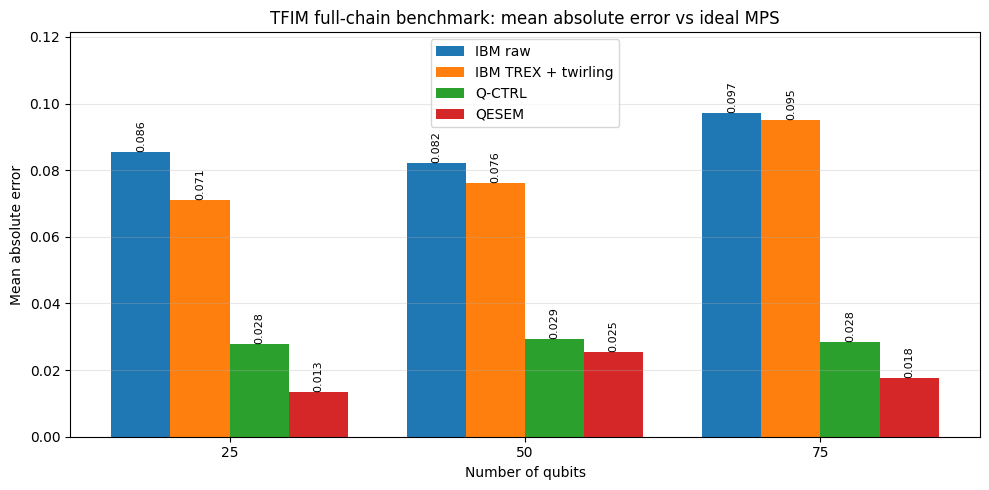

Saved plot: results\tfim_probe\plots\mean_absolute_error_vs_ideal_mps.png


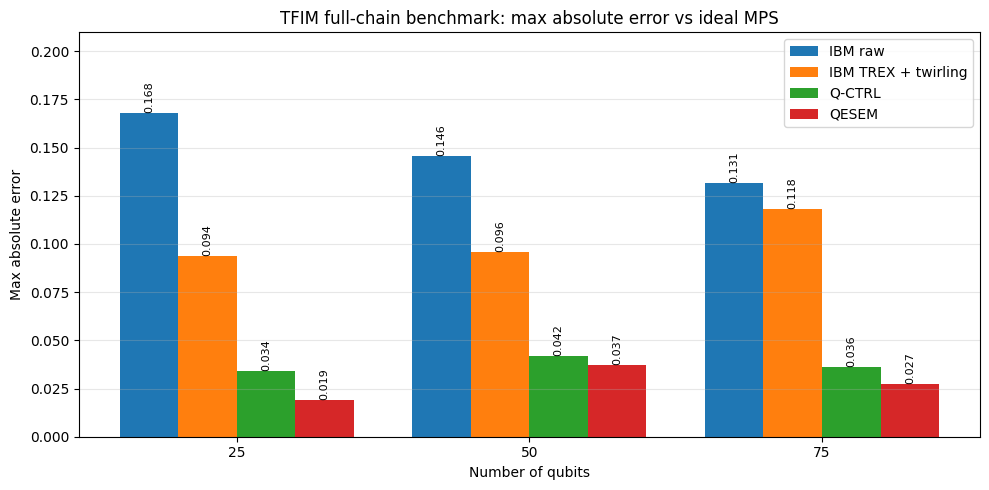

Saved plot: results\tfim_probe\plots\max_absolute_error_vs_ideal_mps.png


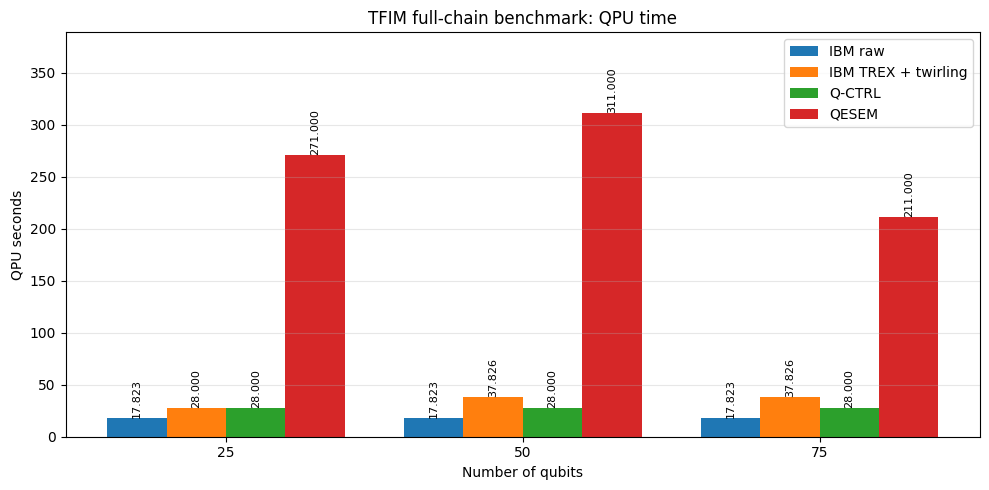

Saved plot: results\tfim_probe\plots\qpu_seconds.png


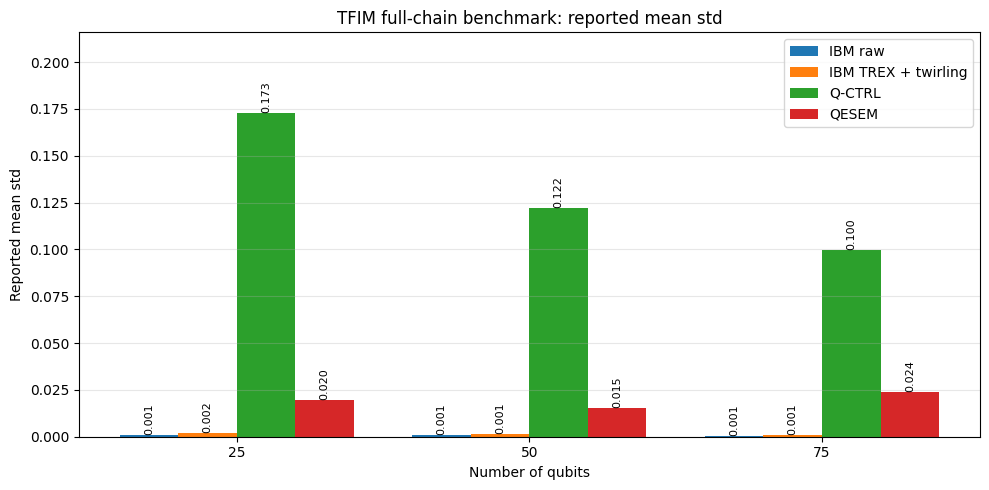

Saved plot: results\tfim_probe\plots\reported_mean_std.png


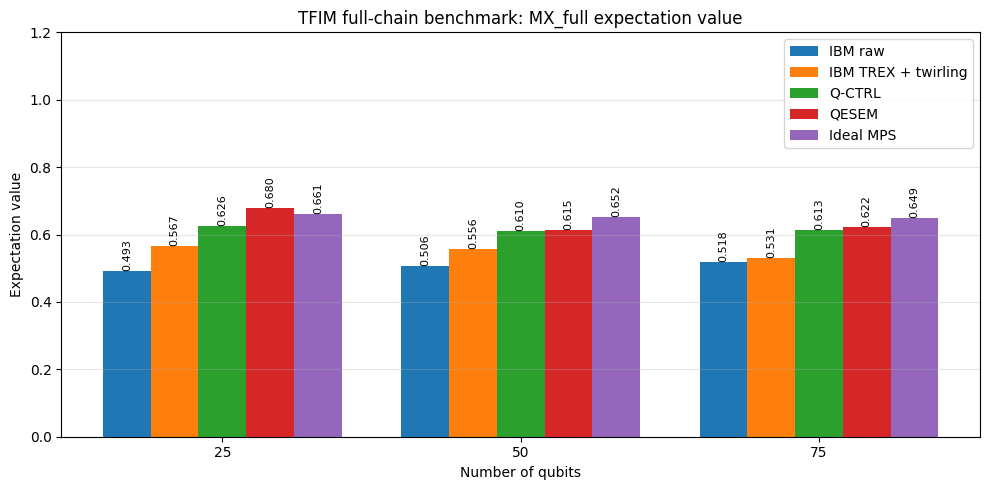

Saved plot: results\tfim_probe\plots\MX_full_expectation_value.png


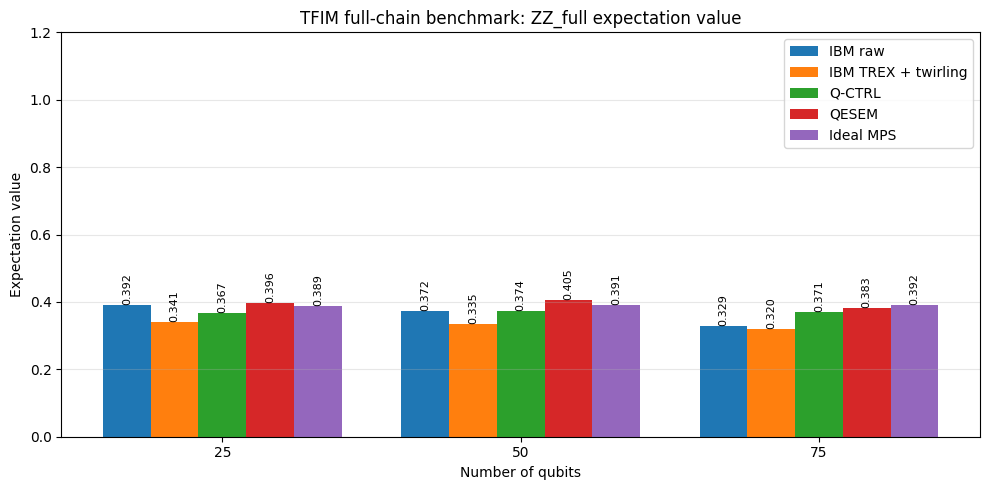

Saved plot: results\tfim_probe\plots\ZZ_full_expectation_value.png


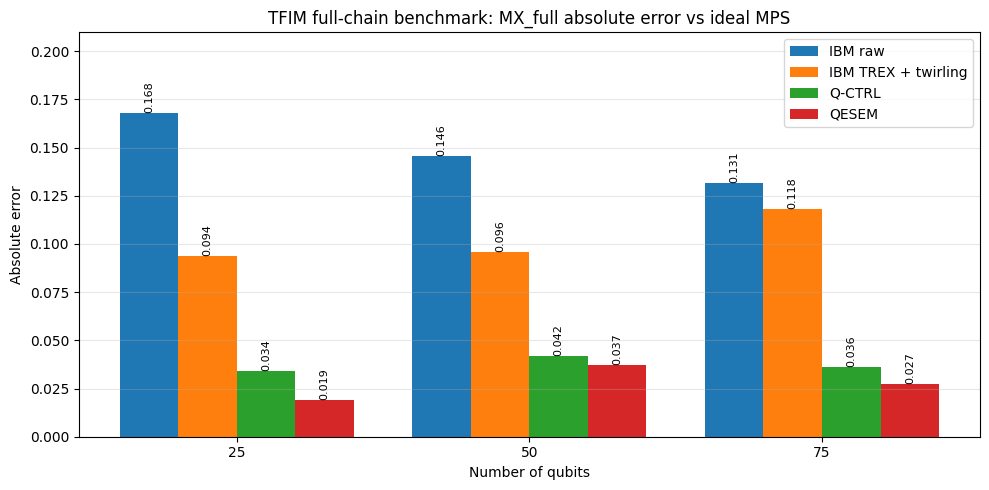

Saved plot: results\tfim_probe\plots\MX_full_absolute_error.png


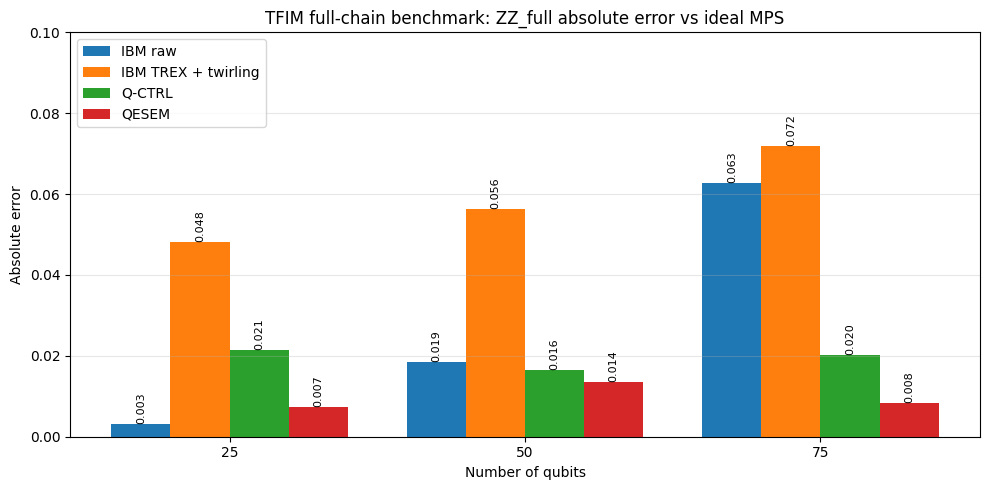

Saved plot: results\tfim_probe\plots\ZZ_full_absolute_error.png
Done.
Plots saved in: results\tfim_probe\plots


In [35]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# Paths
# ============================================================

RESULT_DIR = Path("results/tfim_probe")
PLOT_DIR = RESULT_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

CLEAN_RESULTS_CSV = RESULT_DIR / "tfim_probe_results_no_MZ.csv"
CLEAN_SUMMARY_CSV = RESULT_DIR / "tfim_probe_summary_no_MZ.csv"


# ============================================================
# Load no-MZ CSVs directly
# IMPORTANT: this cell does not recompute or overwrite them
# ============================================================

tfim_df = pd.read_csv(CLEAN_RESULTS_CSV)
summary_df = pd.read_csv(CLEAN_SUMMARY_CSV)

tfim_df["n"] = pd.to_numeric(tfim_df["n"], errors="coerce")
summary_df["n"] = pd.to_numeric(summary_df["n"], errors="coerce")


# ============================================================
# Sanity checks
# ============================================================

check_mz = tfim_df["observable"].astype(str).str.upper().str.match(r"^MZ($|_)")
assert not check_mz.any(), "MZ is still present in tfim_df."

print("Loaded clean results from:", CLEAN_RESULTS_CSV)
print("Loaded clean summary from:", CLEAN_SUMMARY_CSV)
print("Observables found:", sorted(tfim_df["observable"].unique()))
print("Providers found:", sorted(tfim_df["provider"].unique()))
print("n values found:", sorted(tfim_df["n"].dropna().unique()))

if "qpu_seconds" in summary_df.columns:
    print("\nQPU seconds available in summary_df:")
    print(
        summary_df
        .pivot_table(
            index="n",
            columns="provider",
            values="qpu_seconds",
            aggfunc="mean",
        )
    )
else:
    print("\nWARNING: qpu_seconds column not found in summary_df.")
    print("Columns in summary_df:", list(summary_df.columns))


# ============================================================
# Ideal MPS expected values
# These are added as an extra bar column in expectation plots
# ============================================================

mps_reference = {
    25:  {"MX_full": 0.66063421, "ZZ_full": 0.38867674},
    50:  {"MX_full": 0.65197805, "ZZ_full": 0.39098874},
    75:  {"MX_full": 0.64909267, "ZZ_full": 0.39173858}
}

mps_ref_df = (
    pd.DataFrame.from_dict(mps_reference, orient="index")
    .reset_index()
    .rename(columns={"index": "n"})
    .melt(
        id_vars="n",
        var_name="observable",
        value_name="Ideal MPS",
    )
)

mps_ref_df["n"] = pd.to_numeric(mps_ref_df["n"], errors="coerce")
mps_ref_df["observable_key"] = mps_ref_df["observable"].astype(str).str.upper()


# ============================================================
# Title prefix
# ============================================================

mode_suffix = (
    "full-chain"
    if tfim_df["observable"].astype(str).str.endswith("_full").any()
    else "probe"
)

benchmark_title_prefix = f"TFIM {mode_suffix} benchmark"


# ============================================================
# Provider order
# ============================================================

provider_order = [
    p for p in [
        "IBM raw",
        "IBM TREX + twirling",
        "IBM ZNE",
        "Q-CTRL",
        "QESEM",
    ]
    if p in tfim_df["provider"].unique() or p in summary_df["provider"].unique()
]

print("\nProvider order used:", provider_order)


# ============================================================
# Helper functions
# ============================================================

def safe_filename(name):
    return re.sub(r"[^A-Za-z0-9]+", "_", str(name)).strip("_")


def finite_ymax(plot_df, exclude_col="n", default=0.1):
    value_cols = [c for c in plot_df.columns if c != exclude_col]

    if len(value_cols) == 0:
        return default

    values = plot_df[value_cols].to_numpy(dtype=float)
    finite = values[np.isfinite(values)]

    if finite.size == 0:
        return default

    return np.nanmax(finite)


def finite_ymin(plot_df, exclude_col="n", default=0.0):
    value_cols = [c for c in plot_df.columns if c != exclude_col]

    if len(value_cols) == 0:
        return default

    values = plot_df[value_cols].to_numpy(dtype=float)
    finite = values[np.isfinite(values)]

    if finite.size == 0:
        return default

    return np.nanmin(finite)


def grouped_bar(
    plot_df,
    x_col,
    series_cols,
    title,
    ylabel,
    xlabel,
    filename,
    ylim=None,
):
    series_cols = [col for col in series_cols if col in plot_df.columns]

    x_labels = plot_df[x_col].astype(str).tolist()
    x = np.arange(len(plot_df))

    width = 0.8 / max(len(series_cols), 1)

    plt.figure(figsize=(10, 5))

    for i, col in enumerate(series_cols):
        offset = (i - (len(series_cols) - 1) / 2) * width
        y = plot_df[col].astype(float).values

        bars = plt.bar(
            x + offset,
            y,
            width,
            label=col,
        )

        for bar, value in zip(bars, y):
            if np.isfinite(value):
                va = "bottom" if value >= 0 else "top"

                plt.text(
                    bar.get_x() + bar.get_width() / 2,
                    value,
                    f"{value:.3f}",
                    ha="center",
                    va=va,
                    fontsize=8,
                    rotation=90,
                )

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(x, x_labels)

    if ylim is not None:
        plt.ylim(*ylim)

    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()

    filename = Path(filename)
    filename.parent.mkdir(parents=True, exist_ok=True)

    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved plot:", filename)


def provider_pivot(df, value_col):
    plot_df = (
        df.pivot_table(
            index="n",
            columns="provider",
            values=value_col,
            aggfunc="mean",
        )
        .reset_index()
    )

    cols = ["n"] + [p for p in provider_order if p in plot_df.columns]

    return plot_df[cols]


# ============================================================
# Plot 1: Mean absolute error
# ============================================================

plot_df = provider_pivot(summary_df, "mean_absolute_error")
ymax = finite_ymax(plot_df)

grouped_bar(
    plot_df=plot_df,
    x_col="n",
    series_cols=provider_order,
    title=f"{benchmark_title_prefix}: mean absolute error vs ideal MPS",
    ylabel="Mean absolute error",
    xlabel="Number of qubits",
    filename=PLOT_DIR / "mean_absolute_error_vs_ideal_mps.png",
    ylim=(0, max(0.1, ymax * 1.25)),
)


# ============================================================
# Plot 2: Max absolute error
# ============================================================

plot_df = provider_pivot(summary_df, "max_absolute_error")
ymax = finite_ymax(plot_df)

grouped_bar(
    plot_df=plot_df,
    x_col="n",
    series_cols=provider_order,
    title=f"{benchmark_title_prefix}: max absolute error vs ideal MPS",
    ylabel="Max absolute error",
    xlabel="Number of qubits",
    filename=PLOT_DIR / "max_absolute_error_vs_ideal_mps.png",
    ylim=(0, max(0.1, ymax * 1.25)),
)


# ============================================================
# Plot 3: QPU seconds
# This now uses qpu_seconds already present in no-MZ summary_df
# ============================================================

if "qpu_seconds" in summary_df.columns:
    qpu_summary_df = summary_df.dropna(subset=["qpu_seconds"]).copy()

    if not qpu_summary_df.empty:
        plot_df = provider_pivot(qpu_summary_df, "qpu_seconds")
        ymax = finite_ymax(plot_df, default=1)

        grouped_bar(
            plot_df=plot_df,
            x_col="n",
            series_cols=provider_order,
            title=f"{benchmark_title_prefix}: QPU time",
            ylabel="QPU seconds",
            xlabel="Number of qubits",
            filename=PLOT_DIR / "qpu_seconds.png",
            ylim=(0, max(1, ymax * 1.25)),
        )
    else:
        print("Skipping QPU time plot: qpu_seconds exists but all values are NaN.")
else:
    print("Skipping QPU time plot: qpu_seconds column not found.")


# ============================================================
# Plot 4: Reported standard deviation
# ============================================================

if "mean_std" in summary_df.columns:
    plot_df = provider_pivot(summary_df, "mean_std")
    ymax = finite_ymax(plot_df)

    grouped_bar(
        plot_df=plot_df,
        x_col="n",
        series_cols=provider_order,
        title=f"{benchmark_title_prefix}: reported mean std",
        ylabel="Reported mean std",
        xlabel="Number of qubits",
        filename=PLOT_DIR / "reported_mean_std.png",
        ylim=(0, max(0.1, ymax * 1.25)),
    )
else:
    print("Skipping reported std plot: mean_std column not found.")


# ============================================================
# Plot 5: Per-observable expectation values
# Ideal MPS is added as another bar column
# ============================================================

for obs in sorted(tfim_df["observable"].unique()):
    subset = tfim_df[tfim_df["observable"] == obs].copy()

    plot_df = (
        subset
        .pivot_table(
            index="n",
            columns="provider",
            values="expectation_value",
            aggfunc="mean",
        )
        .reset_index()
    )

    obs_key = str(obs).upper()

    mps_obs_ref = (
        mps_ref_df[mps_ref_df["observable_key"] == obs_key]
        [["n", "Ideal MPS"]]
        .copy()
    )

    if not mps_obs_ref.empty:
        plot_df = plot_df.merge(
            mps_obs_ref,
            on="n",
            how="left",
        )

    expectation_series_cols = provider_order.copy()

    if "Ideal MPS" in plot_df.columns:
        expectation_series_cols.append("Ideal MPS")

    cols = ["n"] + [p for p in expectation_series_cols if p in plot_df.columns]
    plot_df = plot_df[cols]

    ymax = finite_ymax(plot_df, default=1.0)
    ymin = finite_ymin(plot_df, default=0.0)

    grouped_bar(
        plot_df=plot_df,
        x_col="n",
        series_cols=expectation_series_cols,
        title=f"{benchmark_title_prefix}: {obs} expectation value",
        ylabel="Expectation value",
        xlabel="Number of qubits",
        filename=PLOT_DIR / f"{safe_filename(obs)}_expectation_value.png",
        ylim=(min(0, ymin * 1.1), max(1.2, ymax * 1.1)),
    )


# ============================================================
# Plot 6: Per-observable absolute errors
# These are already errors relative to Ideal MPS
# ============================================================

for obs in sorted(tfim_df["observable"].unique()):
    subset = tfim_df[tfim_df["observable"] == obs].copy()

    plot_df = (
        subset
        .pivot_table(
            index="n",
            columns="provider",
            values="absolute_error",
            aggfunc="mean",
        )
        .reset_index()
    )

    cols = ["n"] + [p for p in provider_order if p in plot_df.columns]
    plot_df = plot_df[cols]

    ymax = finite_ymax(plot_df)

    grouped_bar(
        plot_df=plot_df,
        x_col="n",
        series_cols=provider_order,
        title=f"{benchmark_title_prefix}: {obs} absolute error vs ideal MPS",
        ylabel="Absolute error",
        xlabel="Number of qubits",
        filename=PLOT_DIR / f"{safe_filename(obs)}_absolute_error.png",
        ylim=(0, max(0.1, ymax * 1.25)),
    )


print("Done.")
print("Plots saved in:", PLOT_DIR)